In [2]:
import numpy as np
import xarray as xr
import wavespectra
from wavespectra import read_swan, read_era5, read_ndbc, read_netcdf, read_wwm
import cmocean
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots
import inspect
from sklearn_extra.cluster import CLARA
from pysofar.sofar import SofarApi
from pysofar.spotter import Spotter
import hdpgpc.GPI_HDP as hdpgp
from hdpgpc.get_data import compute_estimators_LDS
from wavespectra.specdataset import SpecDataset

import xarray as xr
from itertools import combinations
import numpy as np
import xarray as xr

from wavespectra.partition import specpart
from wavespectra.core.utils import (
    set_spec_attributes,
    regrid_spec,
    smooth_spec,
    check_same_coordinates,
    D2R,
    celerity,
    is_overlap,
    waveage,
)

C:\Users\marco\anaconda3\envs\hdpgpc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

### Carga del archivo

In [3]:
ds = read_ndbc('../data/NDBC/dir2017.nc', directional=True).isel(lat=0, lon=0)
ds.to_netcdf("../data/NDBC/dir2017_directional.nc")

In [4]:
# Cargar los datasets
ds_wave = xr.open_dataset("../data/NDBC/dir2017_directional.nc")
ds_meteo = xr.open_dataset("../data/NDBC/meteo2017.nc")
ds_ocean = xr.open_dataset("../data/NDBC/ocean2017.nc")

# Eliminar las dimensiones lat/lon (sólo hay un punto)
#ds_wave = ds_wave.squeeze(["latitude", "longitude"])
ds_meteo = ds_meteo.squeeze(["latitude", "longitude"])
ds_ocean = ds_ocean.squeeze(["latitude", "longitude"])

# Convertir variables codificadas a NumPy arrays para evitar problemas de interpolación
for ds in [ds_meteo, ds_ocean]:
    for var in ds.data_vars:
        ds[var].data = ds[var].values
        
# Interpolar viento y profundidad al tiempo del espectro
meteo_interp = ds_meteo.interp(time=ds_wave.time)

# Combinar todo en un nuevo dataset
ds = ds_wave.assign({
    "wspd": meteo_interp["wind_spd"],
    "wdir": meteo_interp["wind_dir"]
})

depth_value = float(ds_ocean["depth"].values[0])

dpt_da = xr.DataArray(
    data=np.full_like(ds.time, depth_value, dtype=np.float32),
    coords={"time": ds.time},
    dims=["time"],
    name="dpt"
)

ds["dpt"] = dpt_da

ds

C:\Users\marco\AppData\Local\Temp\ipykernel_10568\450414501.py:3: FutureWarning:

In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.

C:\Users\marco\AppData\Local\Temp\ipykernel_10568\450414501.py:14: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ms' instead. To silence this warning use time_unit='ms' in call to decoding function.

C:\Users\marco\AppData\Local\Temp\ipykernel_10568\450414501.py:14: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ns' instead. To silence this warning use time_unit='ns' in call to decoding function.



<xarray.Dataset> Size: 118MB
Dimensions:    (time: 8694, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2017-01-01 ... 2017-12-31T23:00:00
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B ...
    lon        float32 4B ...
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 118MB ...
    wspd       (time) float64 70kB 7.9 7.1 7.4 5.4 4.2 ... 11.3 11.3 10.8 10.4
    wdir       (time) float64 70kB 274.0 258.0 270.0 262.0 ... 25.0 20.0 16.0
    dpt        (time) float32 35kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [5]:
ds = SpecDataset(ds)

In [5]:
data = ds.efth.values
freq = ds.freq.values
data = pd.DataFrame(data, columns=freq)
data = data.to_numpy()
data = data[:, :, np.newaxis]
data = data.astype(np.float64)
print("Shape of the data: ")
print(data.shape)
num_samples, num_obs_per_sample, num_outputs = data.shape

ValueError: Must pass 2-d input. shape=(8694, 47, 36)

In [ ]:
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq[1]-freq[0], num_obs_per_sample)[:, np.newaxis]
hs = 4 * np.sqrt(data[:,:,0] @ interv)
print("Shape of hs: "+str(hs.shape))
plt.plot(hs)
chosen_indexes = np.where((hs > 0.5) & (hs < 2.5))[0]
#chosen_indexes = np.arange(0, num_samples)
print("How much spectra falls in the range 0.5-3.0 Hs: " + str(chosen_indexes.shape[0]))
plt.show()
plt.plot(freq, data[:,:,0][chosen_indexes].T)
plt.show()
lognorm_data = np.log(data + 1e-6) - np.mean(np.log(data+ 1e-6), axis=1)[:,np.newaxis,:]
plt.plot(freq, lognorm_data[:,:,0][chosen_indexes].T)
plt.show()

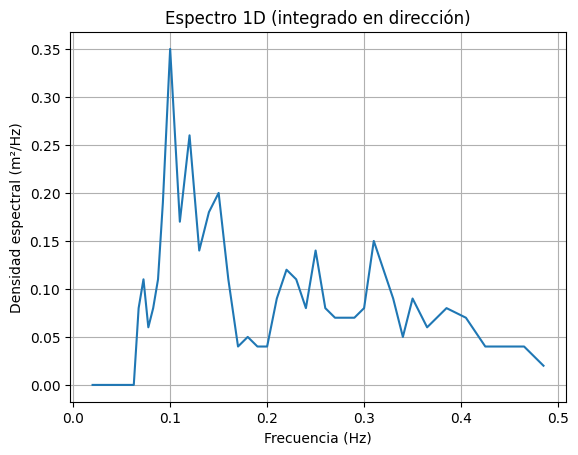

In [5]:
ef = ds.isel(time=4792).spec.oned()

# Acceder a la frecuencia desde las dimensiones
freqs = ef.coords[ef.dims[0]]  # Generalmente 'frequency'

# Graficar
plt.plot(freqs, ef.values)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral (m²/Hz)')
plt.title('Espectro 1D (integrado en dirección)')
plt.grid(True)
plt.show()

In [6]:
dspart = ds.spec.partition.ptm1(
    wspd=ds.wspd,
    wdir=ds.wdir,
    dpt=ds.dpt,
    swells=2,
    smooth=True
)

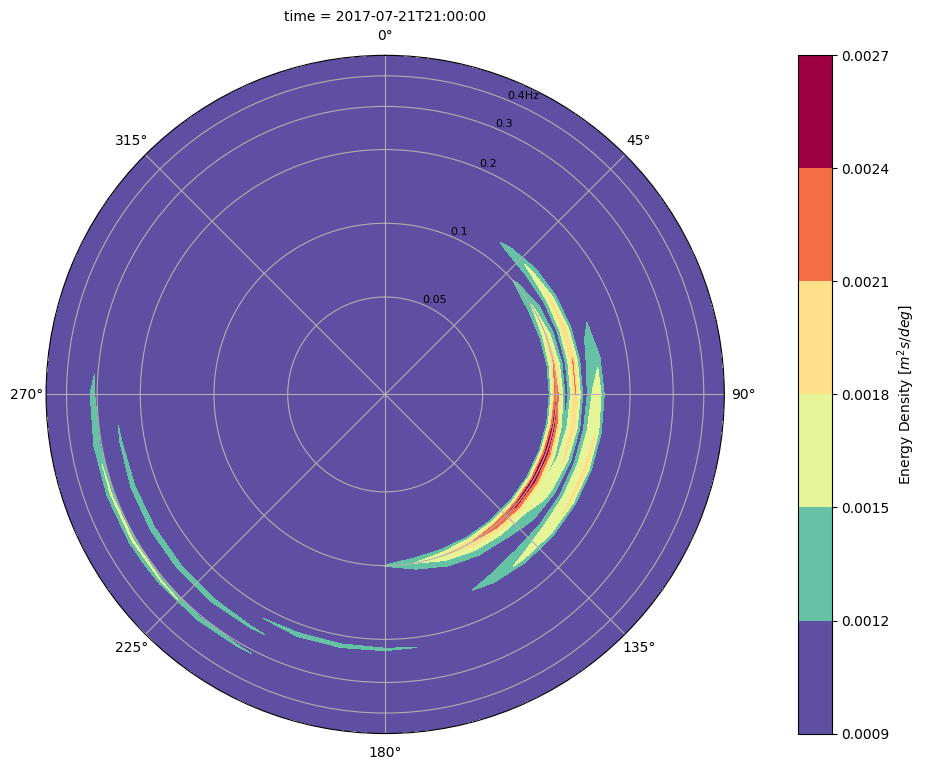

In [7]:
ds2 = ds.isel(time=[4792])  
ds2.spec.plot(
    normalised=False,
    col="time",
    figsize=(15, 8),
    cmap="Spectral_r",
)

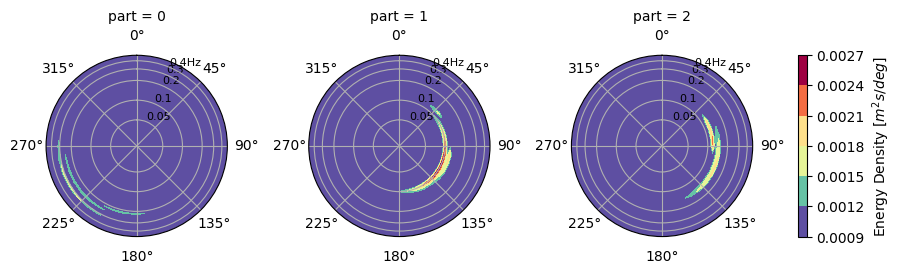

In [9]:
dspart.isel(time=4792, drop=True).spec.plot(col="part", normalised=False, cmap="Spectral_r");

plt.draw()

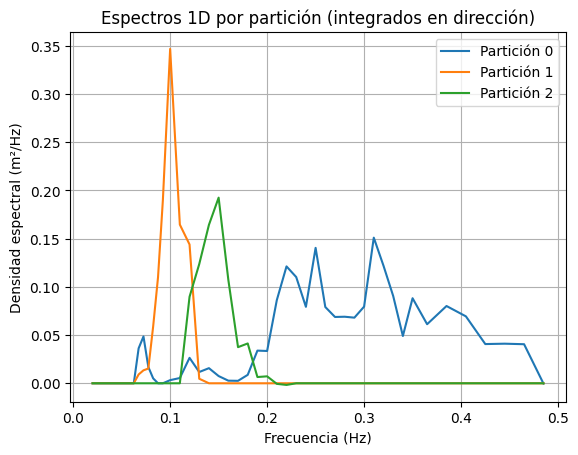

In [24]:
import matplotlib.pyplot as plt

# Seleccionamos el instante que quieres (ejemplo: el primero)
da = dspart.isel(time=4792)  # dims: (part, freq, dir)

# Número de particiones
n_parts = da.sizes['part']

# Iteramos por cada partición
for i in range(n_parts):
    part = da.isel(part=i)  # dims: (freq, dir)
    ef = part.spec.oned()   # integrar sobre dirección → dims: (freq)
    
    freqs = ef[freqs.dims[0]]  # coordenada de frecuencia
    plt.plot(freqs, ef.values, label=f'Partición {i}')

plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral (m²/Hz)')
plt.title('Espectros 1D por partición (integrados en dirección)')
plt.legend()
plt.grid(True)
plt.show()


# Particionamiento Portilla

In [6]:
import numpy as np

def classify_partition_portilla(part, freq, dir, wspd, wdir, g=9.81):
    if part.sum() == 0:
        return "null"

    ipeak = np.unravel_index(np.argmax(part, axis=None), part.shape)
    f_peak = freq[ipeak[0]]
    theta_peak = dir[ipeak[1]]
    cp = g / (2 * np.pi * f_peak)
    Ueff = wspd * np.cos(np.radians(theta_peak - wdir))
    waveage = Ueff / cp
    
    if Ueff <= 0:
        return "swell"
    
    beta_min = cp / Ueff
    
    print(beta_min)

    if beta_min <= 1.3:
        return "wind sea"
    elif beta_min <= 2.0:
        return "old wind sea"
    else:
        return "swell"

In [7]:
def hs_func(spec, freq, dir):
    df = np.diff(freq).mean()
    dtheta = np.deg2rad(np.diff(dir).mean())
    m0 = np.sum(spec) * df * dtheta
    return 4 * np.sqrt(m0)


In [8]:
def get_partition_centroid(part, freq, dir):
    energy = part.sum()
    if energy == 0:
        return 0.0, 0.0
    fx = np.sum(part * freq[:, None]) / energy
    dx = np.sum(part * dir[None, :]) / energy
    return fx, dx

def find_closest_partition(i, centroids, valid_idxs):
    fi, di = centroids[i]
    min_dist = float("inf")
    closest = None
    for j in valid_idxs:
        if j == i:
            continue
        fj, dj = centroids[j]
        dist = (fi - fj)**2 + (di - dj)**2
        if dist < min_dist:
            min_dist = dist
            closest = j
    return closest

In [56]:
def np_portilla(
    spectrum,
    spectrum_smooth,
    freq,
    dir,
    wspd,
    wdir,
    dpt,
    swells=None,
    max_parts=10,
    ihmax=500,
    threshold_energy=0.02,
    combine_energy=0.05,
    max_filter_iter=1,
    freq_window=3,
    dir_window=3
):
    total_energy = spectrum.sum()
    filtered = spectrum_smooth.copy()

    for _ in range(max_filter_iter):
        watershed_map = specpart.partition(filtered.values.astype(np.float32), ihmax)
        nparts = watershed_map.max()

        parts = []
        centroids = []
        energies = []

        # Paso 1: gardar todas as particións (sen filtrar)
        for ipart in range(nparts):
            part = np.where(watershed_map == ipart + 1, spectrum, 0.0)
            energy = part.sum()
            parts.append(part)
            centroids.append(get_partition_centroid(part, freq, dir))
            energies.append(energy)

        # Paso 2: combinar particións de baixa enerxía (< threshold_energy)
        valid_idxs = list(range(len(parts)))
        for i in valid_idxs[:]:
            if energies[i] / total_energy < threshold_energy:
                j = find_closest_partition(i, centroids, valid_idxs)
                if j is not None:
                    parts[j] += parts[i]
                    energies[j] += energies[i]
                    valid_idxs.remove(i)

        if len(valid_idxs) <= max_parts:
            break
        else:
            filtered = smooth_spec(filtered, freq_window, dir_window)

    # Paso 5: combinar particións de baixa enerxía (< combine_energy)
    for i in valid_idxs[:]:
        if energies[i] / total_energy < combine_energy:
            j = find_closest_partition(i, centroids, valid_idxs)
            if j is not None:
                parts[j] += parts[i]
                energies[j] += energies[i]
                valid_idxs.remove(i)

    final_parts = [parts[i] for i in valid_idxs]
    labels = []
    classified_parts = []

    for part in final_parts:
        label = classify_partition_portilla(part, freq, dir, wspd, wdir)
        if label != "null":
            classified_parts.append(part)
            labels.append(label)

    swell_parts = [p for p, l in zip(classified_parts, labels) if l != "wind sea"]
    swell_labels = [l for l in labels if l != "wind sea"]
    hs_vals = [-hs_func(p, freq, dir) for p in swell_parts]
    isort = np.argsort(hs_vals)
    swell_parts = list(np.array(swell_parts)[isort])
    swell_labels = list(np.array(swell_labels)[isort])

    print(labels)
    windsea = [p for p, l in zip(classified_parts, labels) if l == "wind sea"]
    windsea_part = np.sum(windsea, axis=0) if windsea else np.zeros_like(spectrum)
    #windsea_part = windsea[0] if windsea else np.zeros_like(spectrum)

    if swells is not None:
        if len(swell_parts) > swells:
            swell_parts = swell_parts[:swells]
            swell_labels = swell_labels[:swells]
        elif len(swell_parts) < swells:
            for _ in range(swells - len(swell_parts)):
                swell_parts.append(np.zeros_like(spectrum))
                swell_labels.append("null")

    all_parts = [windsea_part] + swell_parts
    all_labels = ["wind sea"] + swell_labels
    return np.array(all_parts), all_labels


In [57]:

def ptm_portilla(
    partition, 
    wspd,
    wdir,
    dpt,
    smooth=True,
    freq_window=3,
    dir_window=3,
    ihmax=10000
):
    check_same_coordinates(wspd, wdir, dpt)

    if smooth:
        dset_smooth = smooth_spec(partition.dset, freq_window, dir_window)
    else:
        dset_smooth = partition.dset

    partitions, labels = np_portilla(
        spectrum=partition.dset.values,
        spectrum_smooth=dset_smooth,
        freq=partition.dset.freq.values,
        dir=partition.dset.dir.values,
        wspd=float(wspd),
        wdir=float(wdir),
        dpt=float(dpt),
        swells=None,
        ihmax=ihmax,
    )

    da = xr.DataArray(
        partitions,
        coords={
            "part": np.arange(len(partitions)),
            "freq": partition.dset.freq,
            "dir": partition.dset.dir,
            "label": ("part", labels),
        },
        dims=("part", "freq", "dir"),
        name="efth"
    )

    return da.to_dataset()

In [58]:
dspart = ptm_portilla(
    partition=ds.isel(time=4792).spec.partition,
    wspd=float(ds.wspd.isel(time=4792).values),
    wdir=float(ds.wdir.isel(time=4792).values),
    dpt=float(ds.dpt.isel(time=4792).values),
    smooth=True
)


0.8318536064258607
1.0314984799012414
1.5907765066510182
0.7367846410482544
['swell', 'swell', 'wind sea', 'wind sea', 'old wind sea', 'wind sea']


In [59]:
dspart

<xarray.Dataset> Size: 55kB
Dimensions:  (part: 4, freq: 47, dir: 36)
Coordinates:
  * part     (part) int32 16B 0 1 2 3
  * freq     (freq) float32 188B 0.02 0.0325 0.0375 0.0425 ... 0.445 0.465 0.485
  * dir      (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    label    (part) <U12 192B 'wind sea' 'swell' 'swell' 'old wind sea'
Data variables:
    efth     (part, freq, dir) float64 54kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

C:\Users\marco\AppData\Local\Temp\ipykernel_10568\2129743184.py:3: DeprecationWarning:

self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.



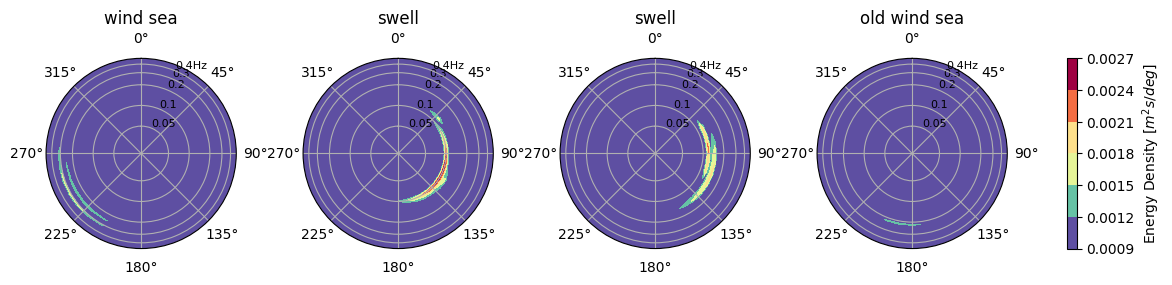

In [60]:
g = dspart.spec.plot(col="part", normalised=False, cmap="Spectral_r")

for i, ax in enumerate(g.axes.flat):
    if i < len(dspart.part):
        label = dspart.label.values[i]
        ax.set_title(label)

In [13]:
dspart

<xarray.Dataset> Size: 55kB
Dimensions:  (part: 4, freq: 47, dir: 36)
Coordinates:
  * part     (part) int32 16B 0 1 2 3
  * freq     (freq) float32 188B 0.02 0.0325 0.0375 0.0425 ... 0.445 0.465 0.485
  * dir      (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    label    (part) <U12 192B 'wind sea' 'swell' 'swell' 'old wind sea'
Data variables:
    efth     (part, freq, dir) float64 54kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

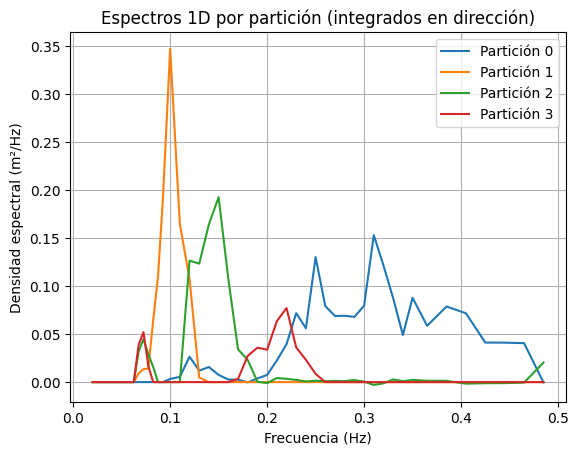

In [61]:
import matplotlib.pyplot as plt

da = dspart 

n_parts = da.sizes['part']

for i in range(n_parts):
    part = da.isel(part=i) 
    ef = part.spec.oned() 

    plt.plot(ef.freq, ef.values, label=f'Partición {i}')

plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral (m²/Hz)')
plt.title('Espectros 1D por partición (integrados en dirección)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
da = dspart 

n_parts = da.sizes['part']

for i in range(n_parts):
    part = da.isel(part=i) 
    ef = part.spec.oned() 
    

In [21]:
ef.freq

<xarray.DataArray 'freq' (freq: 47)> Size: 188B
array([0.02  , 0.0325, 0.0375, 0.0425, 0.0475, 0.0525, 0.0575, 0.0625, 0.0675,
       0.0725, 0.0775, 0.0825, 0.0875, 0.0925, 0.1   , 0.11  , 0.12  , 0.13  ,
       0.14  , 0.15  , 0.16  , 0.17  , 0.18  , 0.19  , 0.2   , 0.21  , 0.22  ,
       0.23  , 0.24  , 0.25  , 0.26  , 0.27  , 0.28  , 0.29  , 0.3   , 0.31  ,
       0.32  , 0.33  , 0.34  , 0.35  , 0.365 , 0.385 , 0.405 , 0.425 , 0.445 ,
       0.465 , 0.485 ], dtype=float32)
Coordinates:
    part     int32 4B 3
  * freq     (freq) float32 188B 0.02 0.0325 0.0375 0.0425 ... 0.445 0.465 0.485
    label    <U12 48B 'old wind sea'
Attributes:
    long_name:      Frequency
    short_name:     frequency
    standard_name:  frequency
    units:          Hz

In [ ]:
from wavespectra.partition import specpart

def np_portilla(
    spectrum,
    spectrum_smooth,
    freq,
    dir,
    wspd,
    wdir,
    dpt,
    swells=None,
    max_parts=10,
    ihmax=100,
    threshold_energy=0.02,
    combine_energy=0.05,
    max_filter_iter=1,
    freq_window=3,
    dir_window=3
):
    total_energy = spectrum.sum()
    filtered = spectrum_smooth.copy()
    #dset_smooth = smooth_spec(partition.dset, freq_window, dir_window)

    for _ in range(max_filter_iter):
        watershed_map = specpart.partition(filtered.values.astype(np.float32), ihmax)
        nparts = watershed_map.max()

        parts = []
        centroids = []
        energies = []

        for ipart in range(nparts):
            part = np.where(watershed_map == ipart + 1, spectrum, 0.0)
            energy = part.sum()
            if energy / total_energy >= threshold_energy:
                parts.append(part)
                centroids.append(get_partition_centroid(part, freq, dir))
                energies.append(energy)

        '''if len(parts) <= max_parts:
            break
        else:
            dset_smooth = smooth_spec(filtered, freq_window, dir_window)'''
    valid_idxs = list(range(len(parts)))
    for i in valid_idxs[:]:
        if energies[i] / total_energy < combine_energy:
            j = find_closest_partition(i, centroids, valid_idxs)
            if j is not None:
                parts[j] += parts[i]
                energies[j] += energies[i]
                valid_idxs.remove(i)

    final_parts = [parts[i] for i in valid_idxs]
    labels = []
    classified_parts = []

    for part in final_parts:
        label = classify_partition_portilla(part, freq, dir, wspd, wdir)
        if label != "null":
            classified_parts.append(part)
            labels.append(label)

    swell_parts = [p for p, l in zip(classified_parts, labels) if l != "wind sea"]
    swell_labels = [l for l in labels if l != "wind sea"]
    hs_vals = [-hs_func(p, freq, dir) for p in swell_parts]
    isort = np.argsort(hs_vals)
    swell_parts = list(np.array(swell_parts)[isort])
    swell_labels = list(np.array(swell_labels)[isort])

    windsea = [p for p, l in zip(classified_parts, labels) if l == "wind sea"]
    windsea_part = windsea[0] if windsea else np.zeros_like(spectrum)

    if swells is not None:
        if len(swell_parts) > swells:
            swell_parts = swell_parts[:swells]
            swell_labels = swell_labels[:swells]
        elif len(swell_parts) < swells:
            for _ in range(swells - len(swell_parts)):
                swell_parts.append(np.zeros_like(spectrum))
                swell_labels.append("null")

    all_parts = [windsea_part] + swell_parts
    all_labels = ["wind sea"] + swell_labels
    return np.array(all_parts), all_labels